<a href="https://colab.research.google.com/github/aliyatoregeldieva2006-coder/house-price-prediction.ipynb/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction

## End-to-End Data Science & Machine Learning Project

This project develops a machine learning solution for predicting residential house prices using the Ames Housing dataset.

The analysis covers the complete data science workflow, including data understanding, exploratory data analysis, data preprocessing, model development, evaluation, and interpretation.

### Objective

The main objective is to predict `SalePrice` based on residential property characteristics and identify the most important factors associated with house prices.

### Models

Three regression models were developed and compared:

- Linear Regression
- Random Forest
- Gradient Boosting

### Best Model

**Gradient Boosting**

- **R²:** 0.9032
- **MAE:** $16,543.63
- **RMSE:** $27,253.95

## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("/content/train (1).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1460, 81)


# 2. Data Understanding


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 2.1 Dataset Overview

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Target variable:", "SalePrice")

Number of rows: 1460
Number of columns: 81
Target variable: SalePrice


### 2.2 First Observations

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 2.3 Descriptive Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### 2.4 Target Variable Analysis

The target variable of this project is `SalePrice`, which represents the sale price of each house.

We will analyze its distribution, central tendency, variability, and potential outliers before building predictive models.

In [8]:
print("Mean SalePrice:", df["SalePrice"].mean())
print("Median SalePrice:", df["SalePrice"].median())
print("Standard Deviation:", df["SalePrice"].std())
print("Minimum SalePrice:", df["SalePrice"].min())
print("Maximum SalePrice:", df["SalePrice"].max())

Mean SalePrice: 180921.19589041095
Median SalePrice: 163000.0
Standard Deviation: 79442.50288288663
Minimum SalePrice: 34900
Maximum SalePrice: 755000


#### Distribution of SalePrice

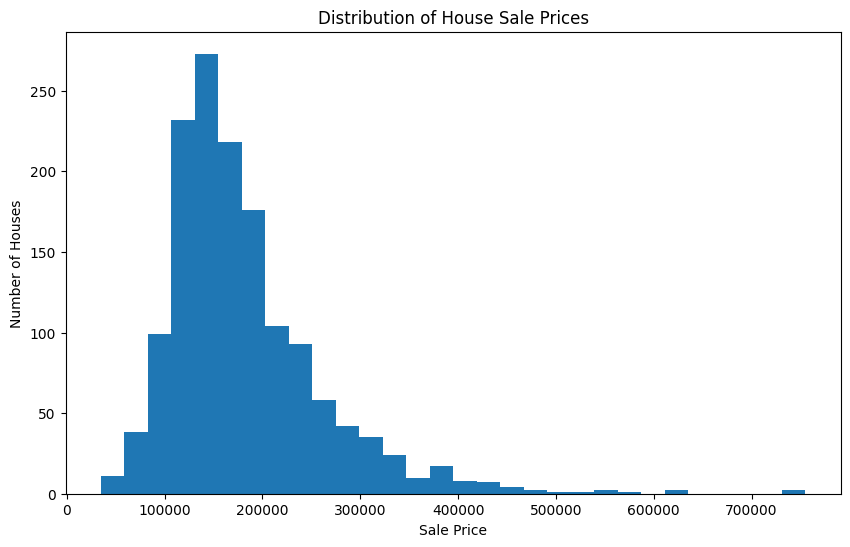

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

#### SalePrice Boxplot


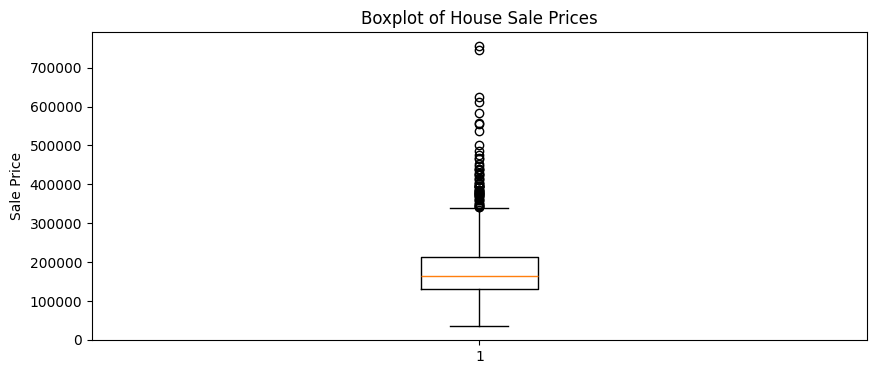

In [10]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["SalePrice"])

plt.title("Boxplot of House Sale Prices")
plt.ylabel("Sale Price")

plt.show()

#3. Exploratory Data Analysis (EDA)

###3.1 Distribution of SalePrice


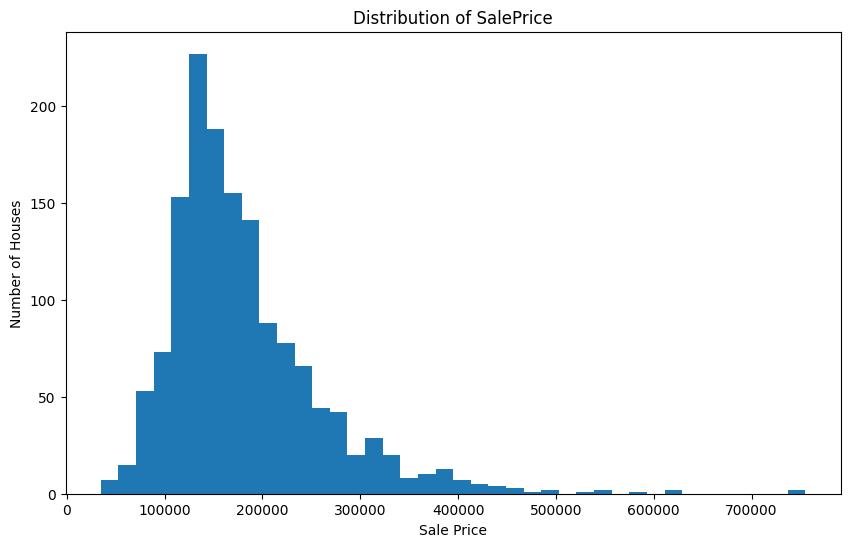

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["SalePrice"], bins=40)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()


### 3.2 Relationship Between Overall Quality and Sale Price

`OverallQual` represents the overall material and finish quality of the house.

We examine its relationship with `SalePrice` to determine whether higher-quality houses tend to have higher sale prices.

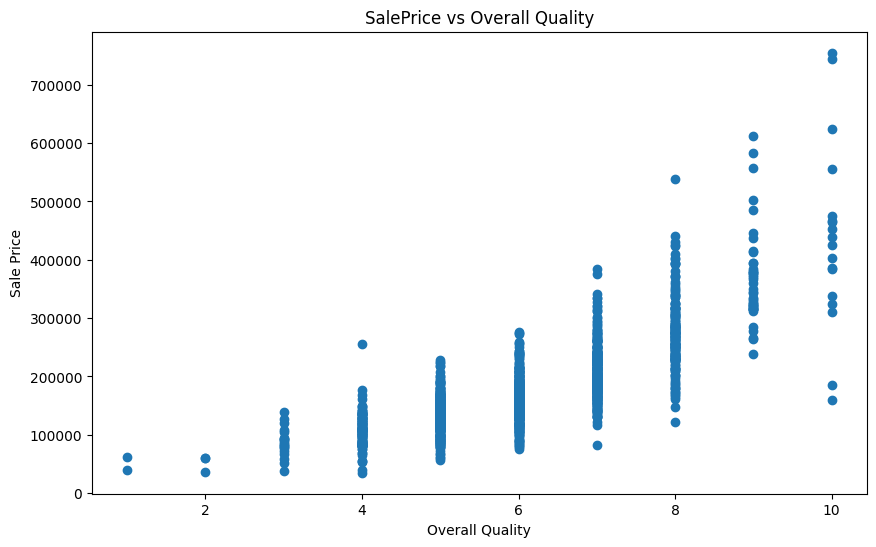

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(df["OverallQual"], df["SalePrice"])

plt.title("SalePrice vs Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()


### 3.3 Correlation Analysis

Correlation analysis is used to identify numerical features that have the strongest relationship with the target variable `SalePrice`.

This helps us understand which characteristics of a house may be important for price prediction.


In [13]:
# Calculate correlations with SalePrice
correlations = df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

print(correlations.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


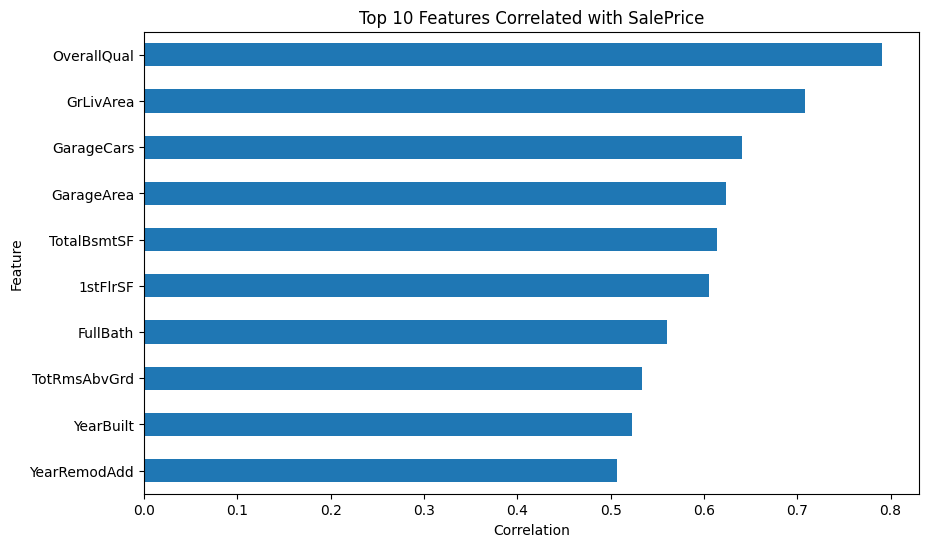

In [14]:
plt.figure(figsize=(10, 6))

correlations.head(11).drop("SalePrice").sort_values().plot(kind="barh")

plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()



### 3.4 Missing Values Analysis

Missing values are present in several features of the dataset.

Before building machine learning models, we need to identify the amount and proportion of missing data and determine appropriate strategies for handling them.

In [16]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [18]:
missing_percent = (df.isnull().sum() / len(df) * 100)

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [19]:
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_dfmissing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


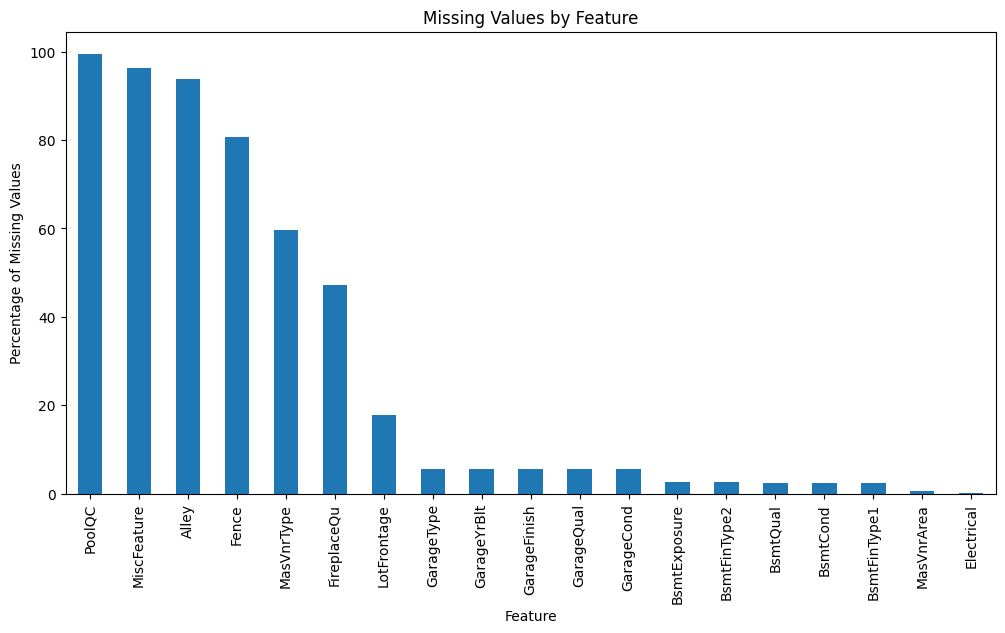

In [20]:
plt.figure(figsize=(12, 6))

missing_df["Percentage"].plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Percentage of Missing Values")
plt.xticks(rotation=90)

plt.show()

### 3.5 Understanding Missing Values

Missing values do not always represent missing or corrupted information.

In this dataset, some missing categorical values indicate that a particular house feature does not exist. For example, a missing `PoolQC` can indicate that the house has no pool.

Therefore, missing values should be handled according to the meaning of each feature rather than simply removing rows.

In [21]:
# Display features with missing values and their percentages

missing_analysis = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing_analysis = (
    missing_analysis[missing_analysis["Missing"] > 0]
    .sort_values("Percentage", ascending=False)
)

missing_analysis

,Missing,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [22]:
print("Features with more than 20% missing values:")
print(missing_analysis[missing_analysis["Percentage"] > 20])

Features with more than 20% missing values:
             Missing  Percentage
PoolQC          1453   99.520548
MiscFeature     1406   96.301370
Alley           1369   93.767123
Fence           1179   80.753425
MasVnrType       872   59.726027
FireplaceQu      690   47.260274


In [23]:
print("Features with less than 5% missing values:")
print(missing_analysis[missing_analysis["Percentage"] < 5])

Features with less than 5% missing values:
              Missing  Percentage
BsmtExposure       38    2.602740
BsmtFinType2       38    2.602740
BsmtQual           37    2.534247
BsmtCond           37    2.534247
BsmtFinType1       37    2.534247
MasVnrArea          8    0.547945
Electrical          1    0.068493


### 3.6 Key Feature Relationships

The correlation analysis identified several important numerical features associated with `SalePrice`.

We further examine the relationships between house quality, living area, construction year, and sale price using scatter plots.

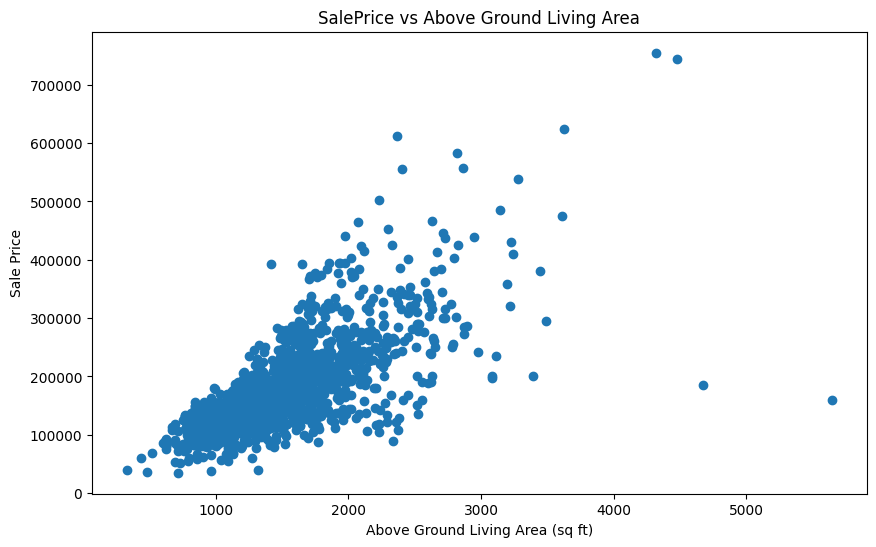

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.title("SalePrice vs Above Ground Living Area")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

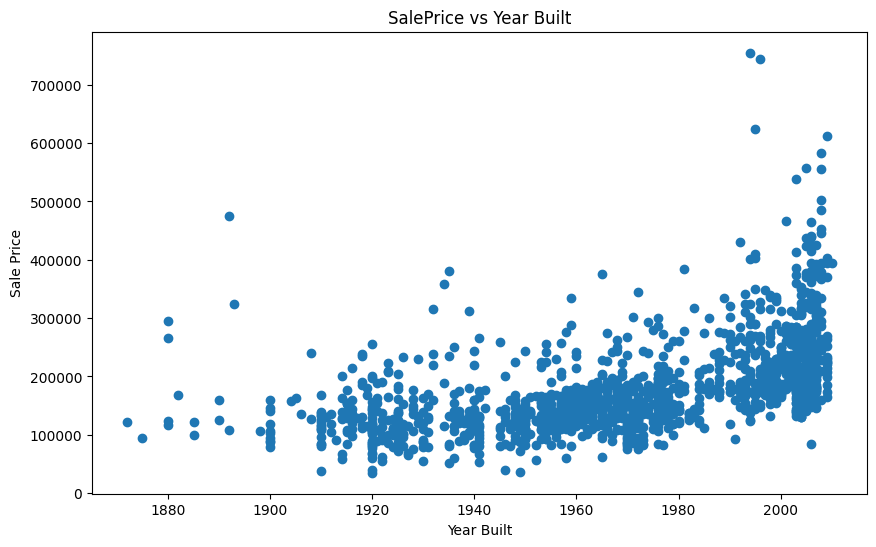

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(df["YearBuilt"], df["SalePrice"])

plt.title("SalePrice vs Year Built")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")

plt.show()

/tmp/ipykernel_509/450486128.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


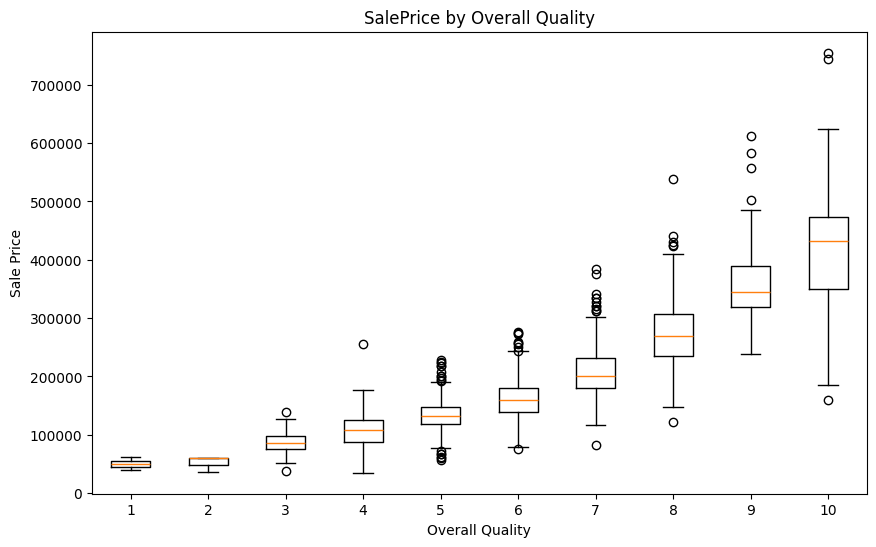

In [26]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df.loc[df["OverallQual"] == q, "SalePrice"].dropna()
     for q in sorted(df["OverallQual"].unique())],
    labels=sorted(df["OverallQual"].unique())
)

plt.title("SalePrice by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

### 3.7 Outlier Detection

Outliers are observations that differ substantially from the majority of the data.

In house price prediction, extreme values in features such as living area may strongly influence the relationship between features and the target variable.

We will identify potential outliers before the modeling stage.

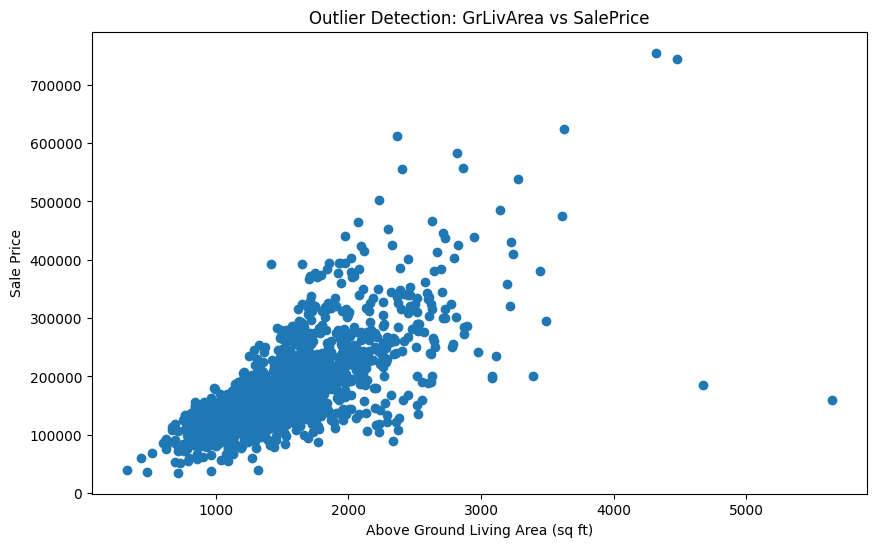

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.title("Outlier Detection: GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()


In [28]:
df.nlargest(10, "GrLivArea")[["GrLivArea", "OverallQual", "YearBuilt", "SalePrice"]]

,GrLivArea,OverallQual,YearBuilt,SalePrice
1298,5642,10,2008,160000
523,4676,10,2007,184750
1182,4476,10,1996,745000
691,4316,10,1994,755000
1169,3627,10,1995,625000
185,3608,10,1892,475000
304,3493,7,1880,295000
1268,3447,8,1935,381000
635,3395,6,1914,200000
769,3279,8,2003,538000


In [29]:
print("95th percentile:", df["GrLivArea"].quantile(0.95))
print("99th percentile:", df["GrLivArea"].quantile(0.99))
print("Maximum:", df["GrLivArea"].max())

95th percentile: 2466.1
99th percentile: 3123.4800000000023
Maximum: 5642


In [30]:
outliers = df[df["GrLivArea"] > df["GrLivArea"].quantile(0.99)]

print("Potential extreme observations:", len(outliers))

Potential extreme observations: 15


### 3.8 Data Cleaning Strategy

Based on the exploratory data analysis, the dataset contains missing values, categorical variables, and potential outliers.

The preprocessing strategy will include:

- removing the identifier column;
- separating features from the target variable;
- identifying numerical and categorical features;
- handling missing numerical values;
- handling missing categorical values;
- encoding categorical variables for machine learning models.


In [31]:
# Separate features and target

X = df.drop(columns=["SalePrice", "Id"])
y = df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 79)
Target shape: (1460,)


In [32]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 36
Number of categorical features: 43


In [33]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType

### 3.9 Train/Test Split

The dataset is divided into training and testing sets.

The training set will be used to train the machine learning models, while the test set will be used to evaluate their performance on unseen data.

We use an 80/20 split and set a random state to ensure reproducibility.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 79)
Testing features: (292, 79)
Training target: (1168,)
Testing target: (292,)


### 3.10 Preprocessing Pipeline

A preprocessing pipeline is created to prepare numerical and categorical features for machine learning.

Numerical missing values are replaced with the median, while categorical missing values are replaced with the most frequent category.

Categorical variables are then transformed using one-hot encoding.

The preprocessing pipeline is fitted only on the training data to prevent data leakage.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical features preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical features preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 4. Modeling


### 4.1 Baseline Model — Linear Regression

A Linear Regression model is used as the baseline model.

The preprocessing pipeline is combined with the model so that all transformations are applied consistently to the training and testing data.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Create the baseline model
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"MAE: ${mae_linear:,.2f}")
print(f"RMSE: ${rmse_linear:,.2f}")
print(f"R² Score: {r2_linear:.4f}")

MAE: $20,466.13
RMSE: $31,294.99
R² Score: 0.8723


### 4.2 Actual vs Predicted Prices

The predicted prices are compared with the actual sale prices.

A well-performing model should produce predictions close to the diagonal line, where predicted and actual values are equal.

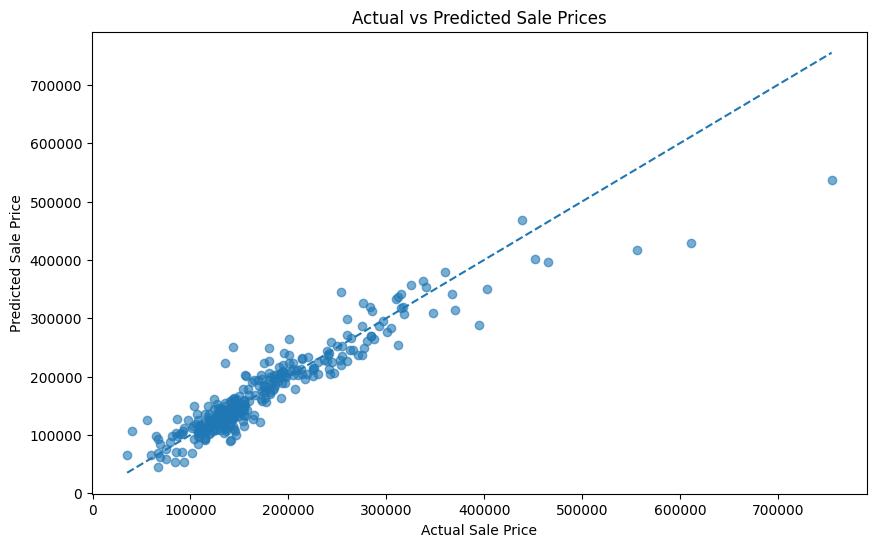

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Sale Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.show()

### 4.3 Residual Analysis

Residuals represent the difference between the actual and predicted sale prices.

Residual analysis helps identify systematic prediction errors and assess whether the model performs consistently across different price ranges.

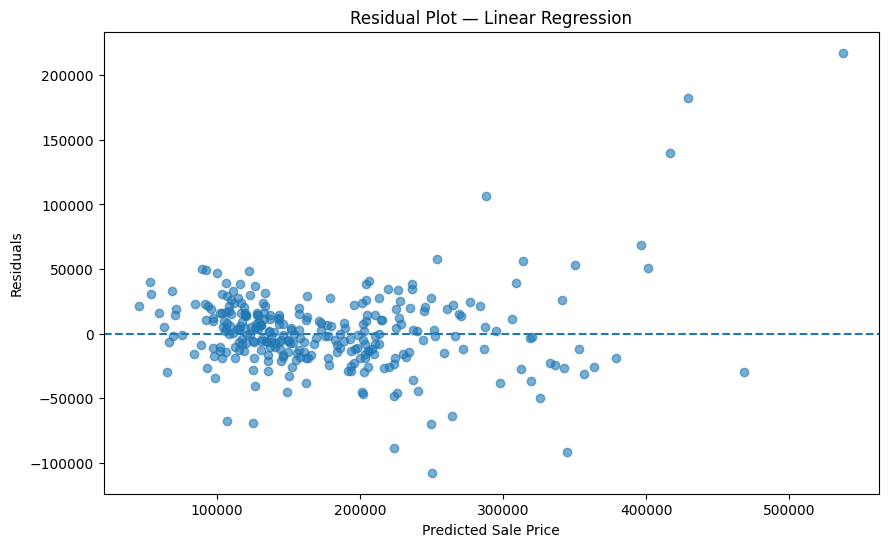

In [45]:
# Calculate residuals
residuals = y_test - y_pred_linear

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_linear, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot — Linear Regression")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.show()

In [46]:
print(f"Mean Residual: {residuals.mean():,.2f}")
print(f"Median Residual: {residuals.median():,.2f}")

Mean Residual: 1,719.79
Median Residual: 393.91


### 4.4 Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Unlike Linear Regression, Random Forest can capture nonlinear relationships and interactions between features.

The model will be trained using the same preprocessing pipeline to ensure a fair comparison with the baseline model.

In [47]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [48]:
# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: ${mae_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"R² Score: {r2_rf:.4f}")

MAE: $17,350.76
RMSE: $28,376.65
R² Score: 0.8950


### 4.5 Gradient Boosting Regression

Gradient Boosting is an ensemble learning method that builds a sequence of decision trees, where each new tree attempts to correct the errors of the previous ones.

It can capture nonlinear relationships and is often effective for structured tabular data such as house price datasets.

In [49]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [50]:
# Make predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Calculate metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE: ${mae_gb:,.2f}")
print(f"RMSE: ${rmse_gb:,.2f}")
print(f"R² Score: {r2_gb:.4f}")

MAE: $16,543.63
RMSE: $27,253.95
R² Score: 0.9032


### 4.6 Model Comparison

The performance of the three regression models is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² Score indicates better explanatory power.

In [51]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

model_comparison = model_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,16543.632116,27253.952711,0.903162
1,Random Forest,17350.759064,28376.645804,0.895020
2,Linear Regression,20466.133696,31294.990974,0.872316


In [52]:
print("=== MODEL COMPARISON ===")

for _, row in model_comparison.iterrows():
    print(
        f"{row['Model']}: "
        f"MAE=${row['MAE']:,.2f}, "
        f"RMSE=${row['RMSE']:,.2f}, "
        f"R²={row['R2 Score']:.4f}"
    )

=== MODEL COMPARISON ===
Gradient Boosting: MAE=$16,543.63, RMSE=$27,253.95, R²=0.9032
Random Forest: MAE=$17,350.76, RMSE=$28,376.65, R²=0.8950
Linear Regression: MAE=$20,466.13, RMSE=$31,294.99, R²=0.8723


### 4.7 Model Performance Visualization

The performance of the regression models is visualized using MAE, RMSE, and R² Score.

This allows us to compare the models and identify the best-performing approach.

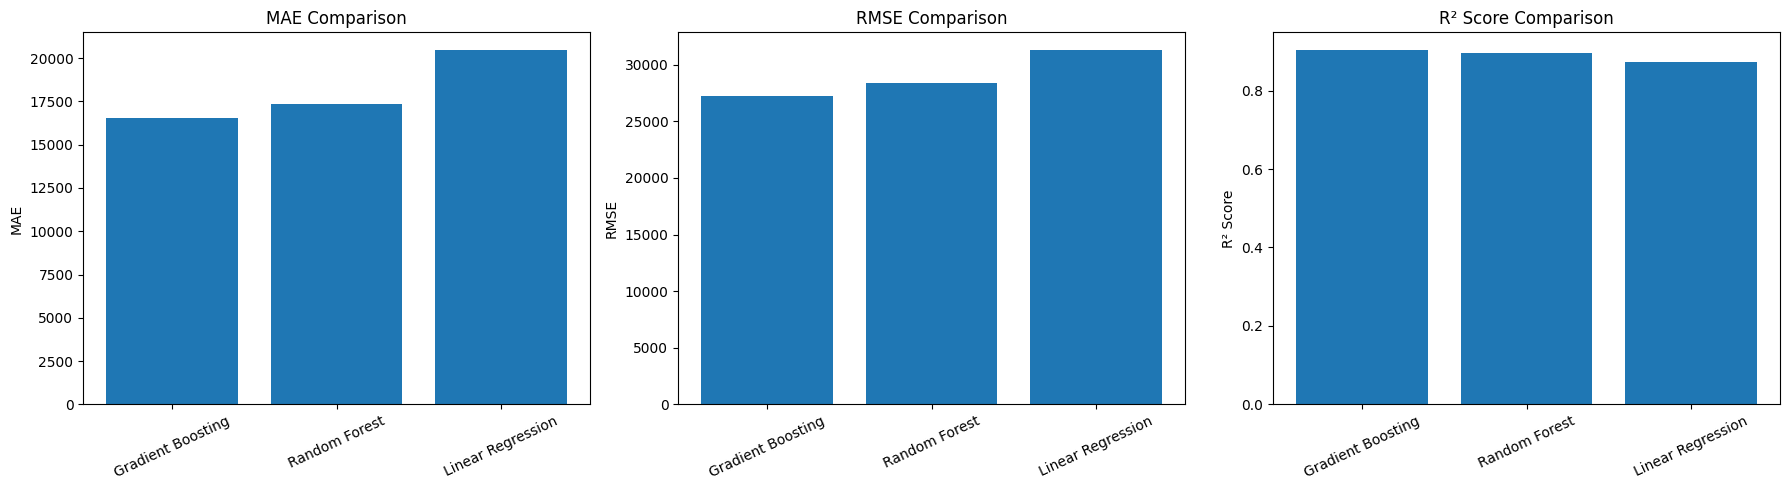

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(model_comparison["Model"], model_comparison["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=25)

# RMSE
axes[1].bar(model_comparison["Model"], model_comparison["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=25)

# R²
axes[2].bar(model_comparison["Model"], model_comparison["R2 Score"])
axes[2].set_title("R² Score Comparison")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 4.8 Feature Importance

Feature importance shows which features contribute most to the predictions of the Random Forest model.

This helps interpret the model and identify the most influential characteristics of a house.

In [54]:
# Extract the trained Random Forest model
rf_model = random_forest_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Select top 20 features
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(20)
)

feature_importance

,Feature,Importance
3,num__OverallQual,0.555588
15,num__GrLivArea,0.122011
11,num__TotalBsmtSF,0.034095
13,num__2ndFlrSF,0.032174
8,num__BsmtFinSF1,0.028809
12,num__1stFlrSF,0.025487
2,num__LotArea,0.017808
26,num__GarageArea,0.015718
25,num__GarageCars,0.013550
5,num__YearBuilt,0.011756


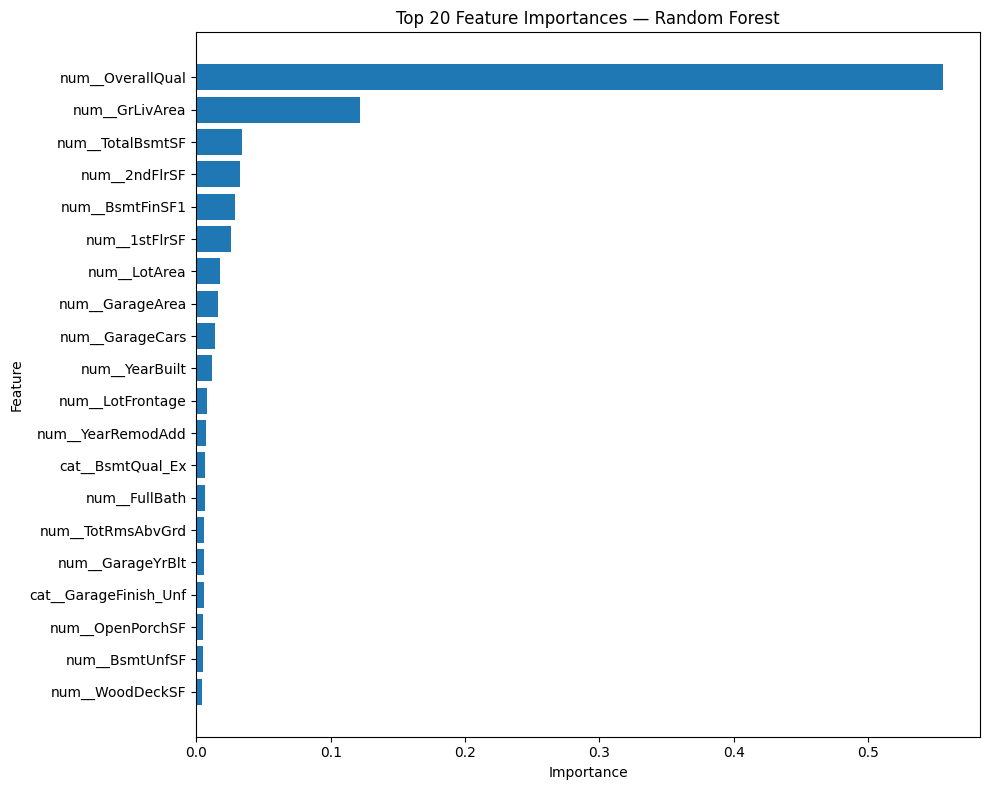

In [55]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"].iloc[::-1],
    feature_importance["Importance"].iloc[::-1]
)

plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 4.9 Best Model — Actual vs Predicted

The best-performing model is selected based on the highest R² Score.

Its predictions are then compared with the actual sale prices to visually evaluate prediction accuracy.

In [56]:
# Select the best model based on R² Score

best_model_name = model_comparison.loc[
    model_comparison["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

# Select predictions of the best model
if best_model_name == "Linear Regression":
    y_pred_best = y_pred_linear
elif best_model_name == "Random Forest":
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_gb

print(f"Best Model R²: {model_comparison['R2 Score'].max():.4f}")

Best Model: Gradient Boosting
Best Model R²: 0.9032


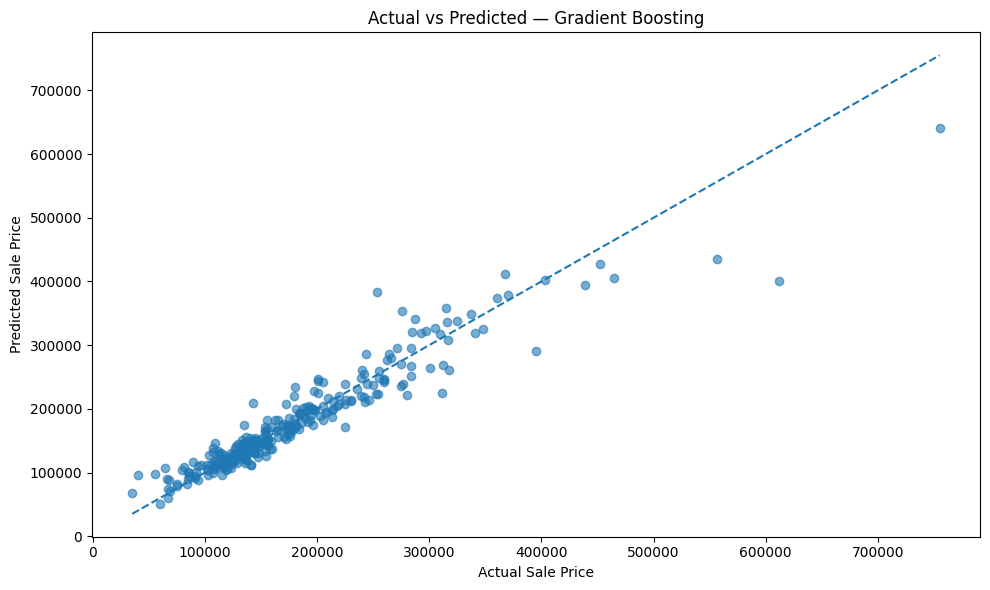

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_best, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted — {best_model_name}")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.tight_layout()
plt.show()

In [58]:
best_row = model_comparison[
    model_comparison["Model"] == best_model_name
].iloc[0]

print("=== BEST MODEL PERFORMANCE ===")
print(f"Model: {best_model_name}")
print(f"MAE: ${best_row['MAE']:,.2f}")
print(f"RMSE: ${best_row['RMSE']:,.2f}")
print(f"R² Score: {best_row['R2 Score']:.4f}")

=== BEST MODEL PERFORMANCE ===
Model: Gradient Boosting
MAE: $16,543.63
RMSE: $27,253.95
R² Score: 0.9032


# 5. Machine Learning Modeling
The Gradient Boosting model achieved the best overall performance among the evaluated models.

It achieved an R² score of 0.9032, meaning that approximately 90.3% of the variation in house sale prices is explained by the model.

The model's MAE was $16,543.63, while the RMSE was $27,253.95.

In [59]:
# Calculate prediction errors

absolute_errors = np.abs(y_test - y_pred_best)
percentage_errors = absolute_errors / y_test * 100

print("=== PREDICTION ERROR ANALYSIS ===")
print(f"Mean Absolute Error: ${absolute_errors.mean():,.2f}")
print(f"Median Absolute Error: ${np.median(absolute_errors):,.2f}")
print(f"Mean Percentage Error: {percentage_errors.mean():.2f}%")
print(f"Median Percentage Error: {np.median(percentage_errors):.2f}%")

=== PREDICTION ERROR ANALYSIS ===
Mean Absolute Error: $16,543.63
Median Absolute Error: $10,483.86
Mean Percentage Error: 9.72%
Median Percentage Error: 6.47%


### 5.1 Prediction Error Distribution

The distribution of absolute prediction errors is examined to understand how frequently the model produces small and large prediction errors.

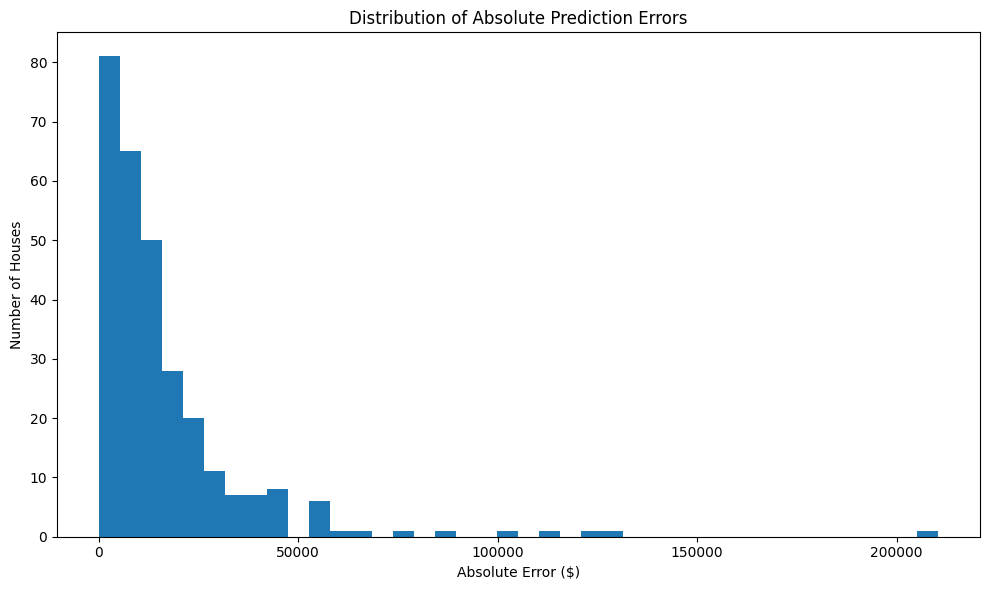

In [60]:
plt.figure(figsize=(10, 6))

plt.hist(absolute_errors, bins=40)

plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error ($)")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

## 5.2 Key Findings

The analysis produced several important findings:

- Overall house quality is one of the strongest predictors of sale price.
- Living area and total basement area have a strong positive relationship with house prices.
- Garage-related characteristics also contribute substantially to price prediction.
- Gradient Boosting achieved the best predictive performance among the evaluated models.
- The best model achieved an R² score of 0.9032, with an MAE of $16,543.63 and an RMSE of $27,253.95.
- The results demonstrate that ensemble tree-based methods can effectively capture nonlinear relationships in residential housing data.

## 5.3 Limitations

Several limitations should be considered when interpreting the results:

- The dataset contains only 1,460 observations and represents a specific housing market.
- The model may not generalize well to other regions or time periods.
- Missing values were handled using statistical imputation and most-frequent category replacement.
- The analysis uses a single train/test split rather than cross-validation for the final comparison.
- Feature importance from tree-based models should be interpreted as predictive importance rather than causal influence.
- House prices can also be affected by external factors that are not included in the dataset, such as local economic conditions, interest rates, and neighborhood-level market trends.

## 5.4 Conclusion

This project developed an end-to-end machine learning workflow for predicting residential house prices.

The analysis included data understanding, exploratory analysis, missing-value assessment, feature preprocessing, model development, model comparison, and interpretation.

Three regression models were evaluated: Linear Regression, Random Forest, and Gradient Boosting.

Gradient Boosting achieved the best performance with an R² score of 0.9032, an MAE of $16,543.63, and an RMSE of $27,253.95.

The project demonstrates the application of statistical analysis and machine learning techniques to a real-world regression problem and highlights the importance of preprocessing, model comparison, and evaluation in a data science workflow.

## 6. Final Portfolio Summary

### Dataset
- 1,460 residential property records
- 80 predictive features
- Target variable: `SalePrice`

### Data Analysis
- Examined numerical and categorical variables
- Analyzed missing values
- Identified the strongest correlations with house prices
- Evaluated important housing characteristics

### Machine Learning Models
Three regression models were evaluated:

1. Linear Regression
2. Random Forest
3. Gradient Boosting

### Best Model

**Gradient Boosting**

- MAE: **$16,543.63**
- RMSE: **$27,253.95**
- R²: **0.9032**

The Gradient Boosting model provided the strongest predictive performance among the evaluated models.

### Key Predictors

The analysis showed that variables related to:

- Overall house quality
- Living area
- Garage characteristics
- Basement area
- House age and renovation
- Neighborhood

play an important role in predicting residential sale prices.

### Conclusion

The project demonstrates a complete data science workflow, from data exploration and preprocessing to machine learning model development, evaluation, and interpretation.

## 6.1 Project Workflow

The project follows the following data science workflow:

**Data Loading → Data Understanding → Exploratory Data Analysis → Data Cleaning → Feature Engineering → Preprocessing → Model Training → Model Evaluation → Model Comparison → Model Interpretation → Final Insights**